# <span style='color: darkblue'>Predicting Insurance Costs</span>

## <span style='color: blue'>Introduction</span>

This project will use the [Medical Cost Data Set](https://www.kaggle.com/datasets/mirichoi0218/insurance?resource=download) from Kaggle.

The dataset contains information on individual medical insurance bills including demographic and personal characteristics of people receiving medical insurance.

The aim is to develop the best predictive model for cost, given patient information using linear regression.

Cost prediction of medical costs allows hospitals to predict revenue and plan necessary procedures needed by the patient population.

The dataset contains the following columns:
* `age`: age of primary beneficiary
* `sex`: insurance contractor gender
* `bmi`: body mass index, providing and understanding of body weights that are relatively high or low relative to height (kg/m<sup>2</sup>)
* `children`: number of children/dependents covered by health insurance
* `smoker`: smoker
* `region`: the beneficiary's regional area in the US
* `charges`: individual medical costs billed by health insurance

*<span style='color: green'>Load required packages...</span>*

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

*<span style='color: green'>Load the dataset...</span>*

In [2]:
insurance = pd.read_csv('insurance.csv')

## <span style='color: blue'>Exploring the Dataset</span>

In [3]:
insurance.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [4]:
insurance.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


The dataset contains 1,338 rows in 7 columns.<br>There does not appear to be any missing values.<br>There are 4 numerical columns and 3 category columns.

*<span style='color: green'>Display summary statistics for the numeric columns...</span>*

In [5]:
insurance.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


This shows `age`, `bmi` and `children` look to be within 'normal' ranges, however, `charges` looks like it may be skewed.

*<span style='color: green'>Plot the distribution of `charges`...</span>*

In [6]:
# Create a function for plotting the distribution of a column
def plot_hist(df, col):
    sns.set_theme(style='white')
    plt.figure(figsize=(12, 6))
    sns.histplot(data=df,
                 x=col,
                 kde=False,
                 color='lightblue',
                 edgecolor='darkblue')
    plt.title('Distribution of Insurance Costs')
    plt.xlabel('')
    plt.ylabel('')
    plt.tick_params(left=False, bottom=False, labelsize=8)
    sns.despine()
    plt.tight_layout()
    plt.show()

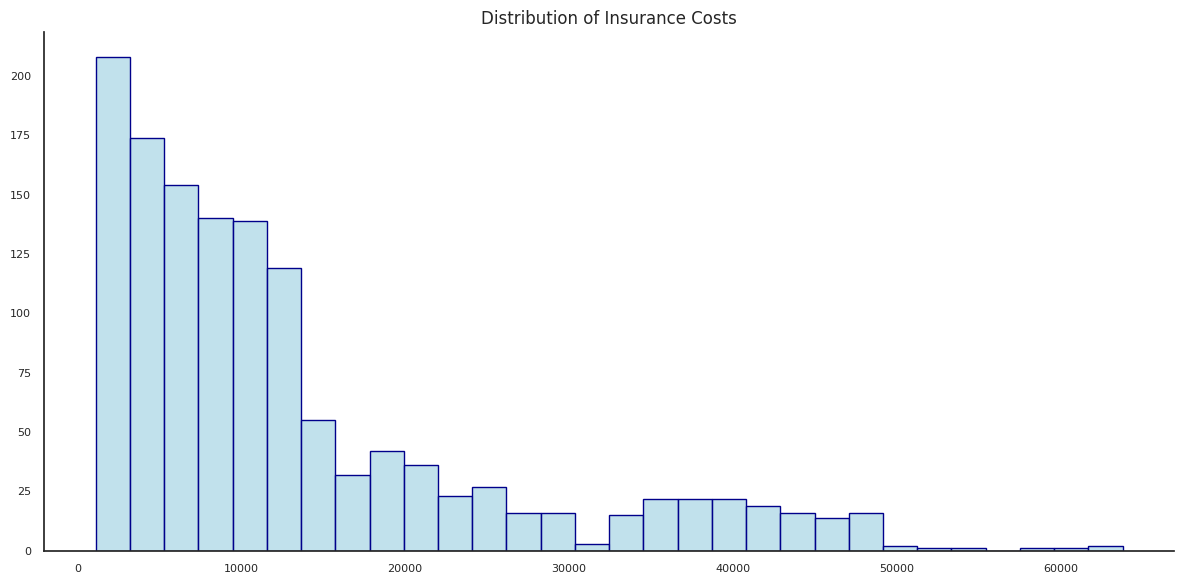

In [7]:
plot_hist(insurance, 'charges')

As the `charges` column is clearly right skewed, that is, lower costs are more frequent than high costs, it is unlikely that the errors in the model would be centered at zero.<br>It would therefore be suitable for log transformation.

*<span style='color: green'>Transform `charges` using the natural log and examine the distribution of the transformed data...</span>*

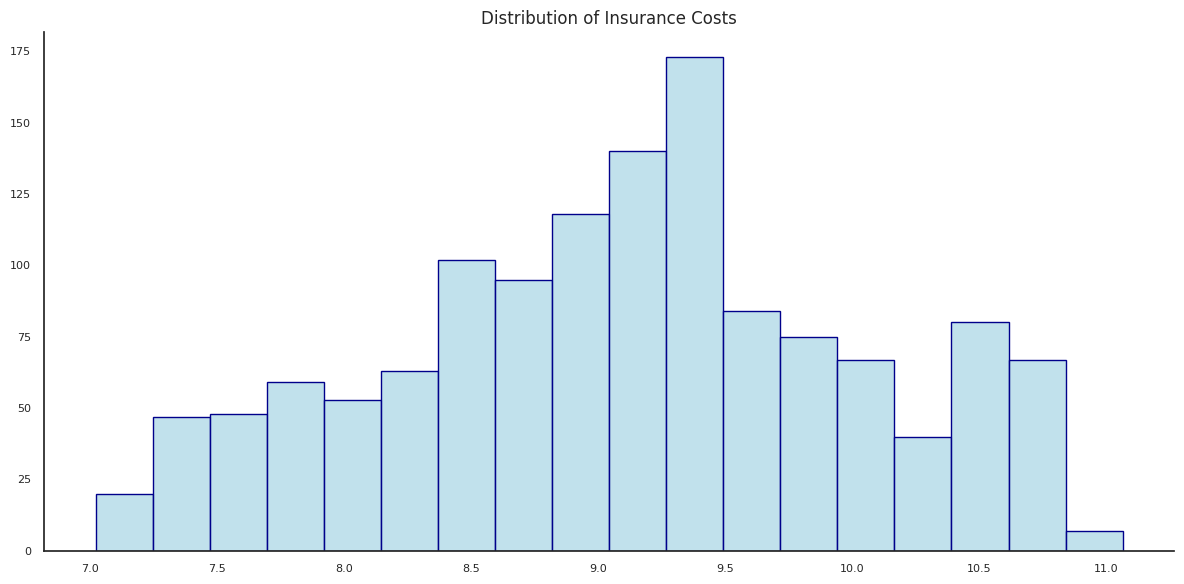

In [8]:
insurance['log_charges'] = np.log(insurance['charges'])
plot_hist(insurance, 'log_charges')

*<span style='color: green'>Examine correlations between numercial columns...</span>*

In [9]:
correlations = insurance.corr(numeric_only=True)
correlations

,age,bmi,children,charges,log_charges
age,1.000000,0.109272,0.042469,0.299008,0.527834
bmi,0.109272,1.000000,0.012759,0.198341,0.132669
children,0.042469,0.012759,1.000000,0.067998,0.161336
charges,0.299008,0.198341,0.067998,1.000000,0.892964
log_charges,0.527834,0.132669,0.161336,0.892964,1.000000


*<span style='color: green'>Visualise the corellations in a heatmap...</span>*

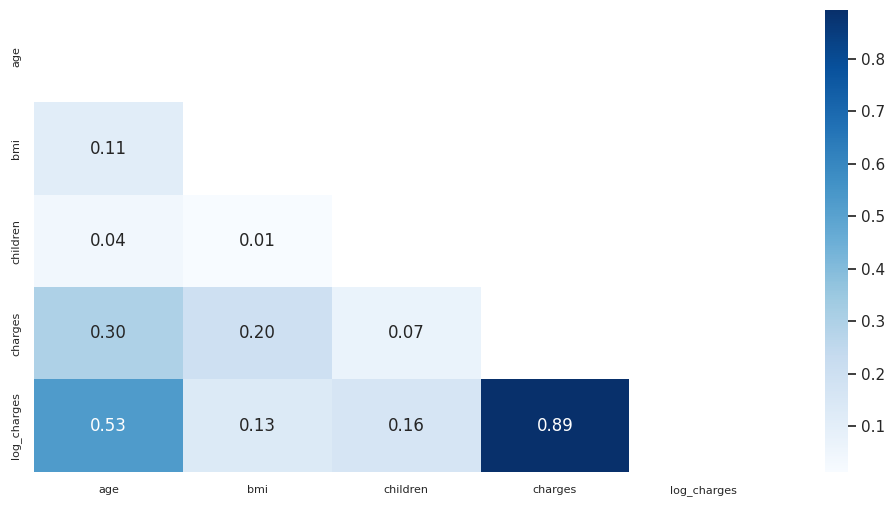

In [10]:
plt.figure(figsize=(12, 6))
mask = np.triu(np.ones_like(correlations, dtype=bool))
sns.heatmap(data=correlations, annot=True, cmap='Blues', fmt='.2f', mask=mask)
plt.xticks(fontsize=8)
plt.yticks(fontsize=8)
plt.show()

Observations:<br>
There is a 30% correlation between `age` and `charges` and 53% with `log_charges`.<br>
There is a 20% correlation between `bmi` and `charges` and 13% with `log_charges`.<br>
There is a 7% correlation between `children` and `charges` and 16% with `log_charges`.

*<span style='color: green'>Examine category column relationships with `log_charges` using boxplots...</span>*

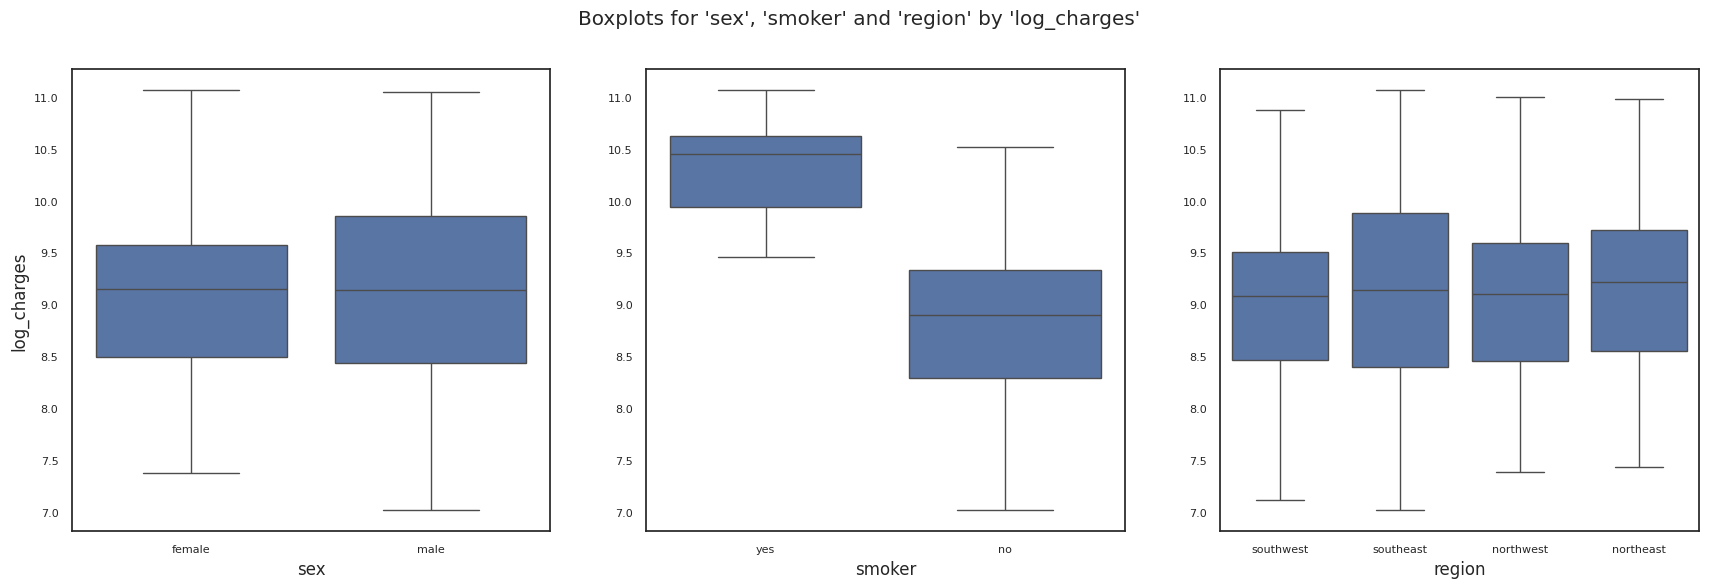

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(21, 6))
categoricals = ['sex', 'smoker', 'region']
for i, category in enumerate(categoricals):
    sns.boxplot(data=insurance, x=category, y='log_charges', ax=axes[i])
    if i > 0:
        axes[i].set_ylabel('')
    axes[i].tick_params(labelsize=8)
fig.suptitle("Boxplots for 'sex', 'smoker' and 'region' by 'log_charges'")
plt.show()

Observations:<br>
There is a slightly wider distribution of charges for males compared to females.<br>
There are much higher costs on average for smokers compared to non-smokers.<br>
The regions are fairly evenly spread with the southeast having the widest spread.

As a result of the above analysis, `age`, `bmi` and `smoker` are the columns most associated with higher charges and will therefore be used in the prediction model.

## <span style='color: blue'>Dividing the Data</span>

*<span style='color: green'>Convert the `smoker` column to numeric so that it can be used in the model...</span>*

In [12]:
insurance['smoker'] = insurance['smoker'].apply(lambda x: 1 if x == 'yes' else 0)

*<span style='color: green'>Set the dependant and independant variables...</span>*

In [13]:
X = insurance[['age', 'bmi', 'smoker']]
y = insurance['log_charges']

*<span style='color: green'>Split the datasets into test and training datasets...</span>*

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=6)

## <span style='color: blue'>Build the Model</span>

*<span style='color: green'>Create and fit the model using the training data...</span>*

In [15]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

*<span style='color: green'>Use the model to make predictions on the training data...</span>*

In [16]:
y_pred_train = model.predict(X_train)

*<span style='color: green'>Calculate the Mean Squared Error (MSE) for the transformed and original insurance charges...</span>*

In [17]:
mse_train_log = mean_squared_error(y_train, y_pred_train)
mse_train_orig = mean_squared_error(y_train, np.exp(y_pred_train))
rmse_train_orig = np.sqrt(mse_train_orig)
print(f'Mean Squared Error on transformed scale: {mse_train_log:.3f}')
print(f'Mean Squared Error on original scale: {mse_train_orig:,.3f}')
print(f'Root Mean Squared Error on original scale: {rmse_train_orig:,.2f}')

Mean Squared Error on transformed scale: 0.218
Mean Squared Error on original scale: 348,356,260.172
Root Mean Squared Error on original scale: 18,664.30


*<span style='color: green'>Calculate the coefficients of determination (R<sup>2</sup>)...</span>*

In [18]:
r2_train_log = r2_score(y_train, y_pred_train)
print(f'Coefficient of Determination on transformed scale: {r2_train_log:.3f}')

Coefficient of Determination on transformed scale: 0.744


The coefficient of determination of 0.744 indicates that the model explains ~74% of the variance in the log transformed target (`log_charges`).<br>
The mean squared error of 0.218 is fairly small so the predictions on the log scale are relatively close, however, the root mean squared error for the original scale is $18,664.30.</br>
This is a decent start but further analysis is required.

## <span style='color: blue'>Residual Diagnostics</span>

*<span style='color: green'>Calculate the training data residuals...</span>*

In [19]:
resids_train = y_train - y_pred_train

*<span style='color: green'>Plot the residuals against the fitted values...</span>*

In [20]:
len(y_pred_train)

1070

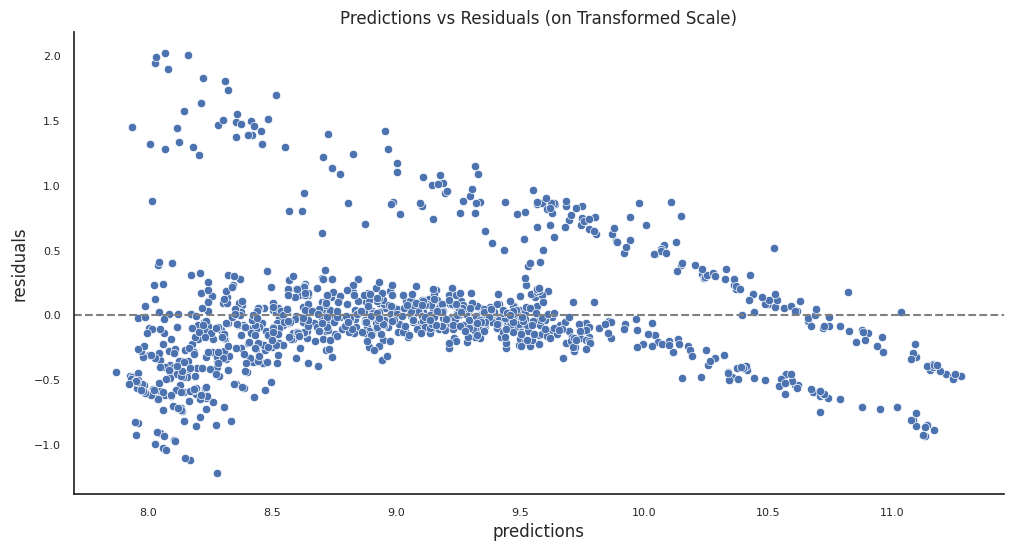

In [21]:
# DataFrame required for the plot...
plot_df = pd.DataFrame({
    'predictions': y_pred_train,
    'actuals': y_train,
    'residuals': resids_train
})

plt.figure(figsize=(12, 6))
sns.scatterplot(data=plot_df,
                x='predictions',
                y='residuals')
plt.axhline(0, c='grey', linestyle='--')
plt.title('Predictions vs Residuals (on Transformed Scale)')
plt.tick_params(labelsize=8)
sns.despine()
plt.show()

The plot above seems to show that the model is, on the transformed scale, underpredicting low charges and overpredicting high charges.<br>
This may indicate that there is some non linear structure in the data that is not being taken into account.

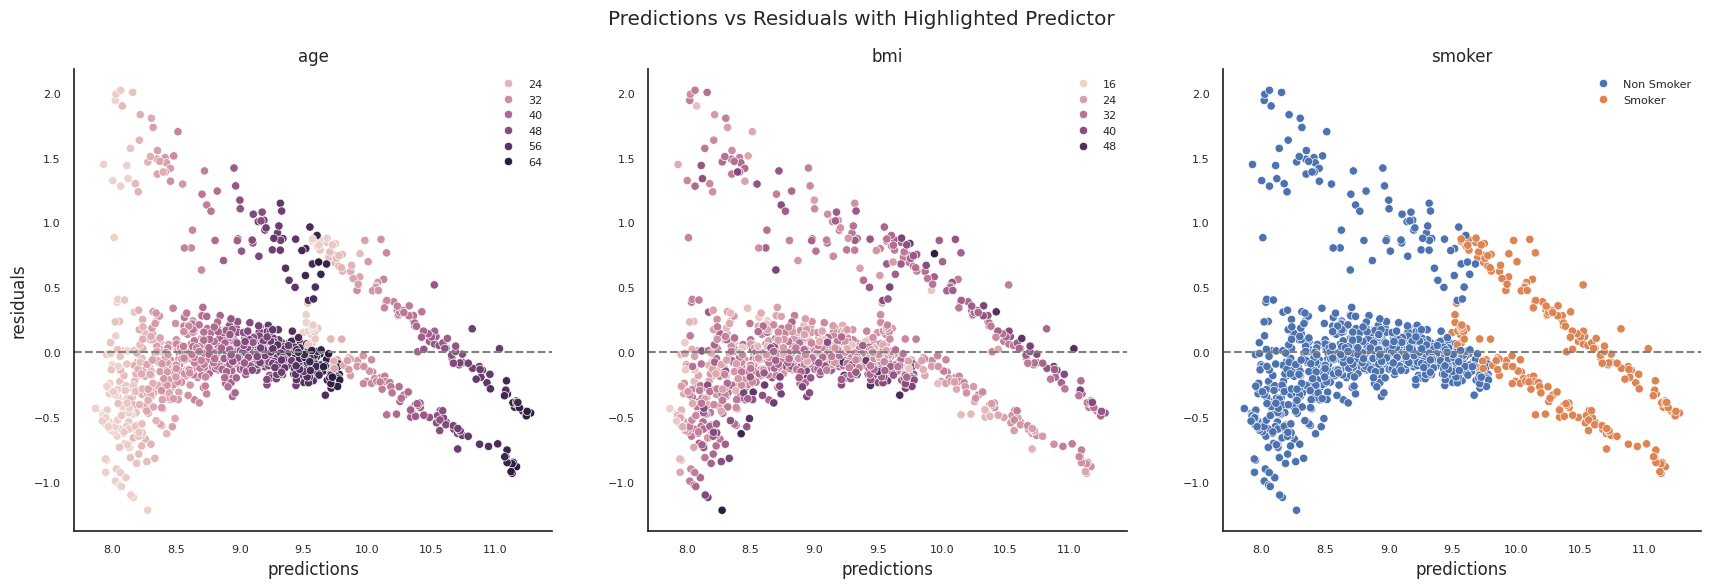

In [22]:
plot_df = pd.DataFrame({
    'predictions': y_pred_train,
    'actuals': y_train,
    'residuals': resids_train,
    'age': X_train['age'],
    'bmi': X_train['bmi'],
    'smoker': X_train['smoker'].apply(lambda x: 'Smoker' if x == 1 else 'Non Smoker')})
predictors = ['age', 'bmi', 'smoker']
fig, axes = plt.subplots(1, 3, figsize=(21, 6))
for i, predictor in enumerate(predictors):
    sns.scatterplot(data=plot_df,
                    x='predictions',
                    y='residuals',
                    hue=predictor,
                    ax=axes[i])
    axes[i].axhline(0, c='grey', linestyle='--')
    axes[i].tick_params(labelsize=8)
    axes[i].legend(frameon=False,
                   fontsize=8)
    if i > 0:
        axes[i].set_ylabel('')
    axes[i].set_title(predictor)
sns.despine()
fig.suptitle('Predictions vs Residuals with Highlighted Predictor')
plt.show()

There is a clear separation between the predictions based on whether the patient is a smoker or not.<br>
It is therefore worth considering creating separate models for each subset of `smoker`.

## <span style='color: blue'>Interpreting the Model</span>

*<span style='color: green'>Retrieve intercept and estimated regression coefficients...</span>*

In [23]:
coef_df = pd.DataFrame(model.coef_, X.columns, columns=['Coefficients'])
coef_df['Original_Scale'] = np.exp(coef_df['Coefficients'])
coef_df['Percentage_Increase_per_Coeff'] = (coef_df['Original_Scale'] - 1) * 100
coef_df

,Coefficients,Original_Scale,Percentage_Increase_per_Coeff
age,0.035930,1.036583,3.658294
bmi,0.010999,1.011060,1.106003
smoker,1.526641,4.602692,360.269209


In [24]:
intercept = model.intercept_
intercept

np.float64(7.0467880632158)

In [25]:
intercept_ns = np.exp(model.intercept_)
intercept_ns

np.float64(1149.1617737741567)

**Model Equation:**

log(`charges`) = 0.036 x `age` + 0.011 x `bmi` + 1.527 x `smoker` + 7.047

This equation can be interpreted as follows:
* `age`: Each increase in year would increase the predicted charges by ~3.6%, holding all other variables constant.
* `bmi`: A unit increase in `bmi` would increase the predicted charges by ~1.1%, holding all other variables constant.
* `smoker`: Being a smoker with constant age and bmi increases the predicted charges by ~4.6 times compared to being a non smoker.

Whilst the R<sup>2</sup> value of 74% on the log scale indicates a solid fit from the model, whether the patient is a smoker or not has by far the biggest impact on the prediction.<br>
The baseline amount of $1,149.16 (the intercept on the original scale) can not be interpreted directly as it is not possible for a patient to have age and bmi of zero.

## <span style='color: blue'>Final Model Evaluation</span>

To judge the model's predictive ability, the performance on data it hasn't seen before should be measured.

*<span style='color: green'>Make predictions on the test data...<span>*

In [26]:
y_pred_test = model.predict(X_test)

*<span style='color: green'>Calculate measures...</span>*

In [27]:
mse_test_log = mean_squared_error(y_test, y_pred_test)
mse_test_orig = mean_squared_error(y_test, np.exp(y_pred_test))
rmse_test_orig = np.sqrt(mse_test_orig)
print(f'Mean Squared Error on transformed scale: {mse_test_log:.3f}')
print(f'Mean Squared Error on original scale: {mse_test_orig:,.3f}')
print(f'Root Mean Squared Error on original scale: {rmse_test_orig:,.2f}')

Mean Squared Error on transformed scale: 0.210
Mean Squared Error on original scale: 366,617,435.066
Root Mean Squared Error on original scale: 19,147.26


In [28]:
r2_test_log = r2_score(y_test, y_pred_test)
print(f'Coefficient of Determination on transformed scale: {r2_test_log:.3f}')

Coefficient of Determination on transformed scale: 0.746


The mean squared error (0.21), RMSE on the original scale ($19,147.26) and R<sup>2</sup> (74.6%) are very similar to the results on the training data indicated that the model is not overfitting the data.

## <span style='color: blue'>Drawing Conclusions</span>

As previously stated, the model is reasonable good and does not overfit the data, however, it does underestimate the higher costs substantially, primarily due to the marked difference in outcomes for smokers and non smokers.<br>
It would definitely be worth exploring other predictive models and techniques to try to improve performance.

## <span style='color: blue'>Next Steps</span>

One of the conclusions from the model above is that there is a clear effect on the outcome based on whether the patient was a smoker or not.<br>
To see if performance can be improved, new models based on separating out the two conditions shall be created and compared to the original model.

*<span style='color: green'>Prepare data for smokers...</span>*

In [29]:
smokers = insurance[insurance['smoker'] == 1]
X = smokers[['age', 'bmi']]
y = smokers['log_charges']
X_train_smokers, X_test_smokers, y_train_smokers, y_test_smokers = train_test_split(X, y, test_size=0.2, random_state=6)

*<span style='color: green'>Create model and predictions on training data...</span>*

In [30]:
model_smokers = LinearRegression()
model_smokers.fit(X_train_smokers, y_train_smokers)
y_train_smokers_pred = model_smokers.predict(X_train_smokers)

*<span style='color: green'>Calculate metrics...</span>*

In [31]:
mse_train_smokers_log = mean_squared_error(y_train_smokers, y_train_smokers_pred)
mse_train_smokers_orig = mean_squared_error(y_train_smokers, np.exp(y_train_smokers_pred))
rmse_train_smokers_orig = np.sqrt(mse_train_smokers_orig)
r2_train_smokers_log = r2_score(y_train_smokers, y_train_smokers_pred)
print(f'Mean Squared Error on transformed scale: {mse_train_smokers_log:.3f}')
print(f'Mean Squared Error on original scale: {mse_train_smokers_orig:,.3f}')
print(f'Root Mean Squared Error on original scale: {rmse_train_smokers_orig:,.2f}')
print(f'Coefficient of Determination on transformed scale: {r2_train_smokers_log:.3f}')

Mean Squared Error on transformed scale: 0.036
Mean Squared Error on original scale: 1,125,968,928.791
Root Mean Squared Error on original scale: 33,555.46
Coefficient of Determination on transformed scale: 0.753


*<span style='color: green'>Analyse residuals...</span>*

In [32]:
resids_train_smokers = y_train_smokers - y_train_smokers_pred

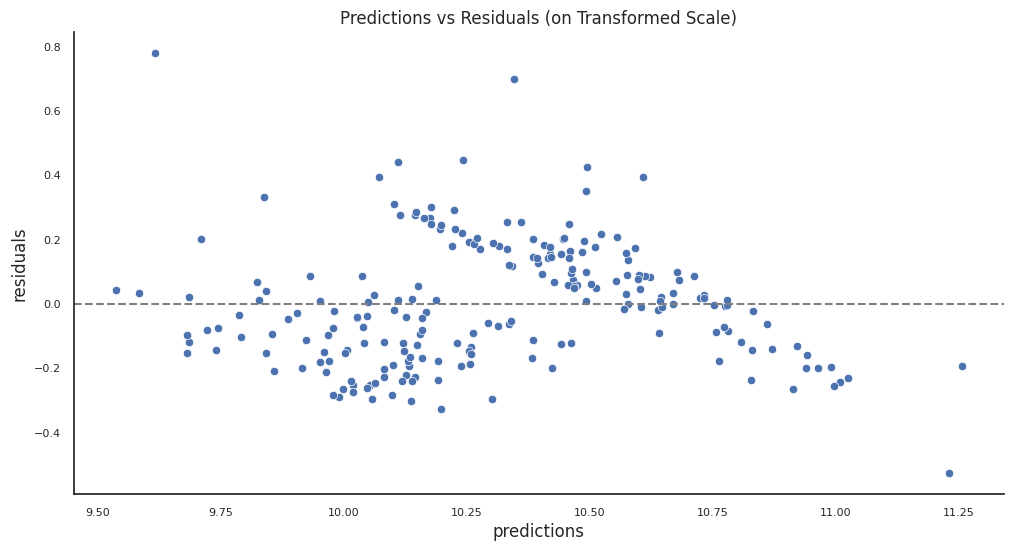

In [33]:
plot_df = pd.DataFrame({
    'predictions': y_train_smokers_pred,
    'actuals': y_train_smokers,
    'residuals': resids_train_smokers
})

plt.figure(figsize=(12, 6))
sns.scatterplot(data=plot_df,
                x='predictions',
                y='residuals')
plt.axhline(0, c='grey', linestyle='--')
plt.title('Predictions vs Residuals (on Transformed Scale)')
plt.tick_params(labelsize=8)
sns.despine()
plt.show()

Whilst the residuals are more evenly spread around the zero line, the performance of the model on the transformed target is not better than the original model.

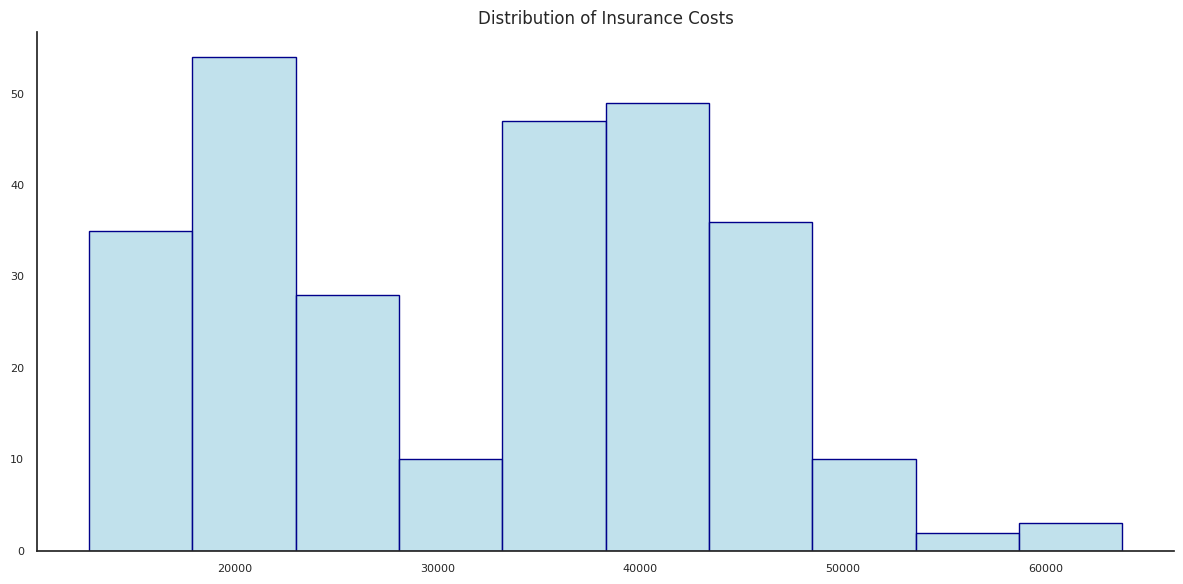

In [34]:
plot_hist(smokers, 'charges')

*<span style='color: green'>Repeat using `charges` as the target...</span>*

Mean Squared Error: 32,272,656.972
Root Mean Squared Error: 5,680.90
Coefficient of Determination: 0.756


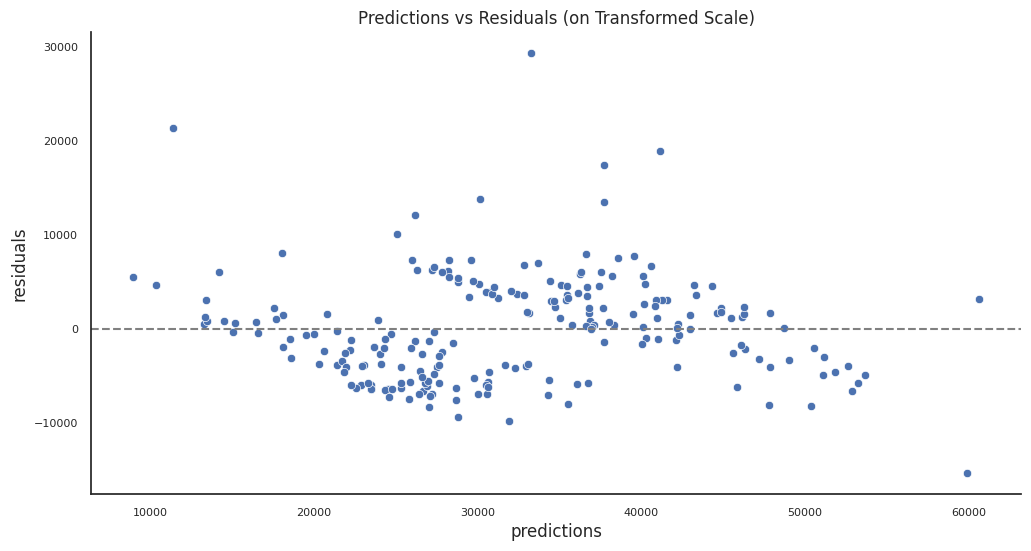

In [35]:
X = smokers[['age', 'bmi']]
y = smokers['charges']
X_train_smokers, X_test_smokers, y_train_smokers, y_test_smokers = train_test_split(X, y, test_size=0.2, random_state=6)
model_smokers = LinearRegression()
model_smokers.fit(X_train_smokers, y_train_smokers)
y_train_smokers_pred = model_smokers.predict(X_train_smokers)
mse_train_smokers = mean_squared_error(y_train_smokers, y_train_smokers_pred)
rmse_train_smokers = np.sqrt(mse_train_smokers)
r2_train_smokers = r2_score(y_train_smokers, y_train_smokers_pred)
print(f'Mean Squared Error: {mse_train_smokers:,.3f}')
print(f'Root Mean Squared Error: {rmse_train_smokers:,.2f}')
print(f'Coefficient of Determination: {r2_train_smokers:.3f}')
resids_train_smokers = y_train_smokers - y_train_smokers_pred
plot_df = pd.DataFrame({
    'predictions': y_train_smokers_pred,
    'actuals': y_train_smokers,
    'residuals': resids_train_smokers
})

plt.figure(figsize=(12, 6))
sns.scatterplot(data=plot_df,
                x='predictions',
                y='residuals')
plt.axhline(0, c='grey', linestyle='--')
plt.title('Predictions vs Residuals (on Transformed Scale)')
plt.tick_params(labelsize=8)
sns.despine()
plt.show()

Basing the model on the original `charges` column as the target improves the coefficient of determination slightly but significanly improves the root mean squared error.

Finally, create a model for non-smokers against the original `charges` column.

Mean Squared Error: 20,928,282.115
Root Mean Squared Error: 4,574.74
Coefficient of Determination: 0.396


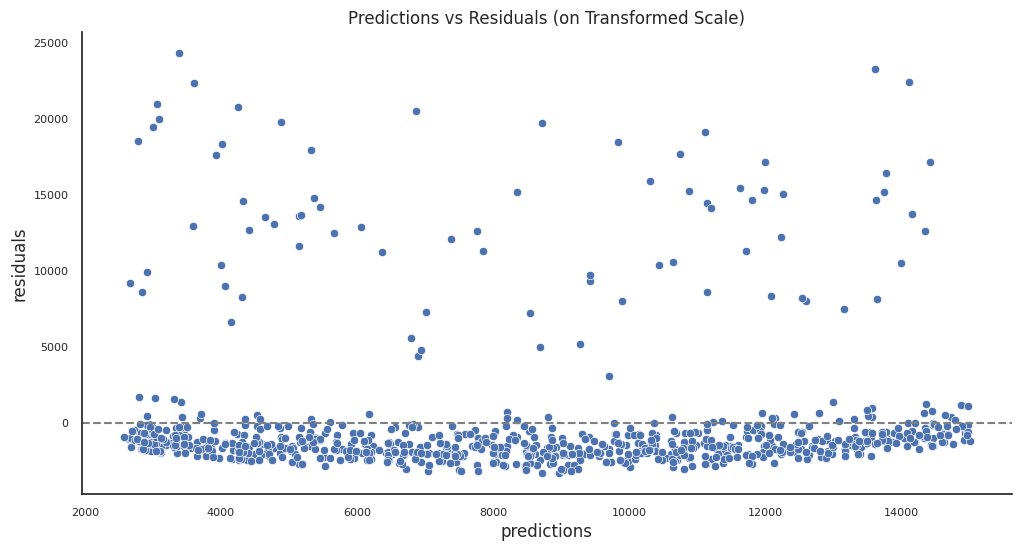

In [36]:
nonsmokers = insurance[insurance['smoker'] == 0]
X = nonsmokers[['age', 'bmi']]
y = nonsmokers['charges']
X_train_nonsmokers, X_test_nonsmokers, y_train_nonsmokers, y_test_nonsmokers = train_test_split(X, y, test_size=0.2, random_state=6)
model_nonsmokers = LinearRegression()
model_nonsmokers.fit(X_train_nonsmokers, y_train_nonsmokers)
y_train_nonsmokers_pred = model_nonsmokers.predict(X_train_nonsmokers)
mse_train_nonsmokers = mean_squared_error(y_train_nonsmokers, y_train_nonsmokers_pred)
rmse_train_nonsmokers = np.sqrt(mse_train_nonsmokers)
r2_train_nonsmokers = r2_score(y_train_nonsmokers, y_train_nonsmokers_pred)
print(f'Mean Squared Error: {mse_train_nonsmokers:,.3f}')
print(f'Root Mean Squared Error: {rmse_train_nonsmokers:,.2f}')
print(f'Coefficient of Determination: {r2_train_nonsmokers:.3f}')
resids_train_nonsmokers = y_train_nonsmokers - y_train_nonsmokers_pred
plot_df = pd.DataFrame({
    'predictions': y_train_nonsmokers_pred,
    'actuals': y_train_nonsmokers,
    'residuals': resids_train_nonsmokers
})

plt.figure(figsize=(12, 6))
sns.scatterplot(data=plot_df,
                x='predictions',
                y='residuals')
plt.axhline(0, c='grey', linestyle='--')
plt.title('Predictions vs Residuals (on Transformed Scale)')
plt.tick_params(labelsize=8)
sns.despine()
plt.show()

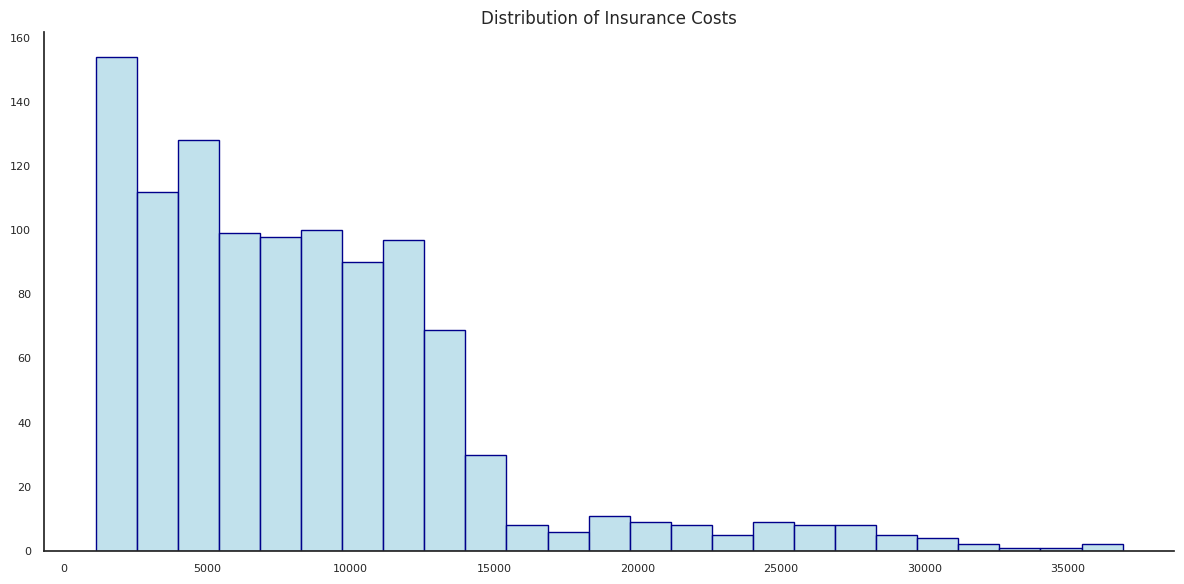

In [37]:
plot_hist(nonsmokers, 'charges')

The distribution of `charges` for nonsmokers is actually still right skewed so using `log_charges` may have been more successful.